BITCOIN DATA ANALYSIS Project

1... Data Collection

In [2]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [5]:
import yfinance as yf

In [6]:
bitcoin = yf.download(tickers="BTC-USD", start ="2017-01-01", end = "2026-06-12", interval ="1d")

[*********************100%***********************]  1 of 1 completed


In [7]:
bitcoin

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2017-01-01,998.325012,1003.080017,958.698975,963.658020,147775008
2017-01-02,1021.750000,1031.390015,996.702026,998.617004,222184992
2017-01-03,1043.839966,1044.079956,1021.599976,1021.599976,185168000
2017-01-04,1154.729980,1159.420044,1044.400024,1044.400024,344945984
2017-01-05,1013.380005,1191.099976,910.416992,1156.729980,510199008
...,...,...,...,...,...
2026-06-07,63239.519531,64128.042969,60724.066406,60866.941406,36006496194
2026-06-08,63090.589844,64185.765625,62384.667969,63244.085938,34133252457


In [8]:
bitcoin = bitcoin.reset_index()

In [9]:
bitcoin.columns.droplevel(1)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [10]:
bitcoin.columns= bitcoin.columns.droplevel(1)


In [11]:
bitcoin

Price,Date,Close,High,Low,Open,Volume
0,2017-01-01,998.325012,1003.080017,958.698975,963.658020,147775008
1,2017-01-02,1021.750000,1031.390015,996.702026,998.617004,222184992
2,2017-01-03,1043.839966,1044.079956,1021.599976,1021.599976,185168000
3,2017-01-04,1154.729980,1159.420044,1044.400024,1044.400024,344945984
4,2017-01-05,1013.380005,1191.099976,910.416992,1156.729980,510199008
...,...,...,...,...,...,...
3444,2026-06-07,63239.519531,64128.042969,60724.066406,60866.941406,36006496194
3445,2026-06-08,63090.589844,64185.765625,62384.667969,63244.085938,34133252457
3446,2026-06-09,61643.781250,63486.089844,60756.687500,63092.890625,40144449754
3447,2026-06-10,61449.289062,62788.277344,60788.023438,61643.207031,27493506779


In [12]:
bitcoin.columns.name = None

In [13]:
bitcoin

,Date,Close,High,Low,Open,Volume
0,2017-01-01,998.325012,1003.080017,958.698975,963.658020,147775008
1,2017-01-02,1021.750000,1031.390015,996.702026,998.617004,222184992
2,2017-01-03,1043.839966,1044.079956,1021.599976,1021.599976,185168000
3,2017-01-04,1154.729980,1159.420044,1044.400024,1044.400024,344945984
4,2017-01-05,1013.380005,1191.099976,910.416992,1156.729980,510199008
...,...,...,...,...,...,...
3444,2026-06-07,63239.519531,64128.042969,60724.066406,60866.941406,36006496194
3445,2026-06-08,63090.589844,64185.765625,62384.667969,63244.085938,34133252457
3446,2026-06-09,61643.781250,63486.089844,60756.687500,63092.890625,40144449754
3447,2026-06-10,61449.289062,62788.277344,60788.023438,61643.207031,27493506779


In [14]:
bitcoin.shape

(3449, 6)

In [15]:
bitcoin["Date"].min()

Timestamp('2017-01-01 00:00:00')

In [16]:
bitcoin["Date"].max()

Timestamp('2026-06-11 00:00:00')

2... OLHC  CHART

In [17]:
bitcoin.dtypes

Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object

In [18]:
bitcoin.duplicated().sum()

np.int64(0)

In [19]:
bitcoin = bitcoin.sort_values(by = ["Date"])

In [20]:
data = bitcoin.copy()

In [21]:
bitcoin_Sample = data[0:100]

In [22]:
import plotly.graph_objs as go

In [23]:
trace =  go.Candlestick(
    x= bitcoin_Sample["Date"],
    high = bitcoin_Sample["High"],
    open = bitcoin_Sample["Open"],
    close = bitcoin_Sample["Close"],
    low = bitcoin_Sample["Low"],
)

In [24]:
candle_data = [trace]

layout ={

    "title":"Bitcoin Historical Price",
    "xaxis" :{"title":"Date"},
}

In [25]:
fig = go.Figure(data = candle_data, layout = layout)

In [26]:
fig = go.Figure(data = candle_data, layout = layout)

In [27]:
fig.update_layout(xaxis_rangeslider_visible = False)

3.... Is Bitcoin TOO Risky ??(Volatility Analysis)

In [28]:
data["daily_Return"] = data["Close"].pct_change()

In [29]:
data.head()

,Date,Close,High,Low,Open,Volume,daily_Return
0,2017-01-01,998.325012,1003.080017,958.698975,963.658020,147775008,NaN
1,2017-01-02,1021.750000,1031.390015,996.702026,998.617004,222184992,0.023464
2,2017-01-03,1043.839966,1044.079956,1021.599976,1021.599976,185168000,0.021620
3,2017-01-04,1154.729980,1159.420044,1044.400024,1044.400024,344945984,0.106233
4,2017-01-05,1013.380005,1191.099976,910.416992,1156.729980,510199008,-0.122410


In [30]:
data["Volatility_30"] = data["daily_Return"].rolling(30).std()
data["Volatility_90"] = data["daily_Return"].rolling(90).std()

In [31]:
px.line(data, 
        x="Date", 
        y=["Volatility_30", "Volatility_90"],
        title = "Bitcoin Volatility Over Time",
        labels = {
                    "value": "Volatility(risk)",
                    "variable" : "window"
                })

In [34]:
data[['Volatility_30','Volatility_90']].describe().T

,count,mean,std,min,25%,50%,75%,max
Volatility_30,3419.0,0.032451,0.014294,0.008887,0.022534,0.029165,0.038823,0.09133
Volatility_90,3359.0,0.033644,0.011726,0.014488,0.025944,0.031061,0.038919,0.07474


In [35]:
data[['Volatility_30','Volatility_90']].describe()

,Volatility_30,Volatility_90
count,3419.000000,3359.000000
mean,0.032451,0.033644
std,0.014294,0.011726
min,0.008887,0.014488
25%,0.022534,0.025944
50%,0.029165,0.031061
75%,0.038823,0.038919
max,0.091330,0.074740


How much Would 1 Lakh in Bitcoin be Worth Today?

In [37]:
data["Cumulative_return"] = (1+ data["daily_Return"]).cumprod()

In [38]:
invesment = 100000

In [40]:
data["invesment_value"] = invesment * data["Cumulative_return"]

In [41]:
data

,Date,Close,High,Low,Open,Volume,daily_Return,Volatility_30,Volatility_90,Cumulative_return,invesment_value
0,2017-01-01,998.325012,1003.080017,958.698975,963.658020,147775008,NaN,NaN,NaN,NaN,NaN
1,2017-01-02,1021.750000,1031.390015,996.702026,998.617004,222184992,0.023464,NaN,NaN,1.023464,1.023464e+05
2,2017-01-03,1043.839966,1044.079956,1021.599976,1021.599976,185168000,0.021620,NaN,NaN,1.045591,1.045591e+05
3,2017-01-04,1154.729980,1159.420044,1044.400024,1044.400024,344945984,0.106233,NaN,NaN,1.156667,1.156667e+05
4,2017-01-05,1013.380005,1191.099976,910.416992,1156.729980,510199008,-0.122410,NaN,NaN,1.015080,1.015080e+05
...,...,...,...,...,...,...,...,...,...,...,...
3444,2026-06-07,63239.519531,64128.042969,60724.066406,60866.941406,36006496194,0.038972,0.020954,0.020422,63.345623,6.334562e+06
3445,2026-06-08,63090.589844,64185.765625,62384.667969,63244.085938,34133252457,-0.002355,0.020822,0.020275,63.196443,6.319644e+06
3446,2026-06-09,61643.781250,63486.089844,60756.687500,63092.890625,40144449754,-0.022932,0.020387,0.020400,61.747207,6.174721e+06
3447,2026-06-10,61449.289062,62788.277344,60788.023438,61643.207031,27493506779,-0.003155,0.020404,0.020393,61.552389,6.155239e+06


In [42]:
final_value = data["invesment_value"].iloc[-1]

In [43]:
final_value

np.float64(6366769.730328928)

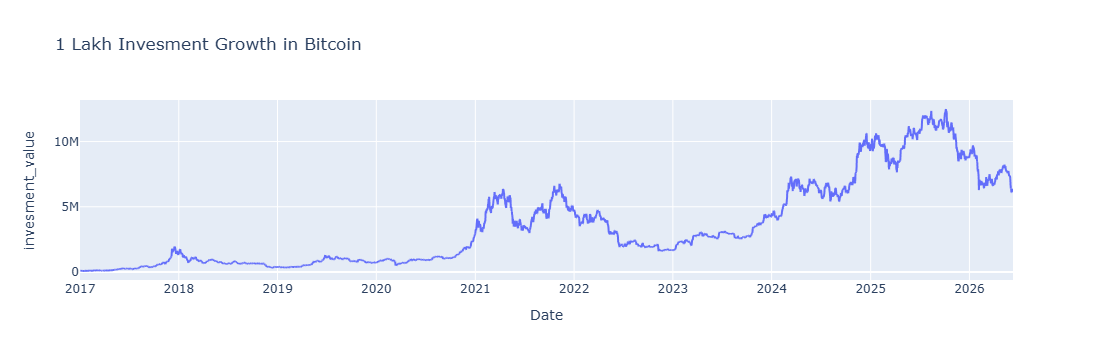

In [51]:
px.line(data,
       x= "Date",
       y = "invesment_value",
       title = "1 Lakh Invesment Growth in Bitcoin", 
        labels={
        "Ivestment Growth" :"Investment value(rupee)"}
    )


4....  Bitcoin Crash Analysis

In [59]:
worst_days = data.nsmallest(10,"daily_Return")[["Date","Close","daily_Return"]]

In [60]:
worst_days

,Date,Close,daily_Return
1166,2020-03-12,4970.788086,-0.371695
256,2017-09-14,3154.949951,-0.187411
380,2018-01-16,11490.500000,-0.168548
1989,2022-06-13,22487.388672,-0.159747
400,2018-02-05,6955.270020,-0.159688
2138,2022-11-09,15880.780273,-0.143490
10,2017-01-11,777.757019,-0.143136
3322,2026-02-05,62702.097656,-0.141299
907,2019-06-27,11182.806641,-0.140857
1599,2021-05-19,37002.441406,-0.137661


In [68]:
worst_days["crash_label"]="BTC | "+worst_days["Date"].dt.strftime("%Y-%m-%d")

In [69]:
worst_days

,Date,Close,daily_Return,crash_label
1166,2020-03-12,4970.788086,-0.371695,BTC | 2020-03-12
256,2017-09-14,3154.949951,-0.187411,BTC | 2017-09-14
380,2018-01-16,11490.500000,-0.168548,BTC | 2018-01-16
1989,2022-06-13,22487.388672,-0.159747,BTC | 2022-06-13
400,2018-02-05,6955.270020,-0.159688,BTC | 2018-02-05
2138,2022-11-09,15880.780273,-0.143490,BTC | 2022-11-09
10,2017-01-11,777.757019,-0.143136,BTC | 2017-01-11
3322,2026-02-05,62702.097656,-0.141299,BTC | 2026-02-05
907,2019-06-27,11182.806641,-0.140857,BTC | 2019-06-27
1599,2021-05-19,37002.441406,-0.137661,BTC | 2021-05-19


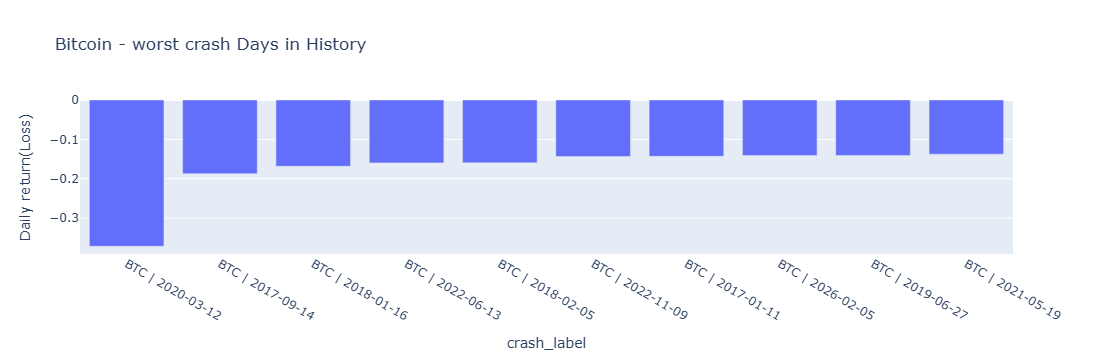

In [72]:
px.bar(worst_days,
      x = "crash_label",
      y = "daily_Return",
      title = "Bitcoin - worst crash Days in History",
      labels={"daily_Return":"Daily return(Loss)",
             "Crash_day":"Crash_Date"})


In [73]:
data

,Date,Close,High,Low,Open,Volume,daily_Return,Volatility_30,Volatility_90,Cumulative_return,invesment_value
0,2017-01-01,998.325012,1003.080017,958.698975,963.658020,147775008,NaN,NaN,NaN,NaN,NaN
1,2017-01-02,1021.750000,1031.390015,996.702026,998.617004,222184992,0.023464,NaN,NaN,1.023464,1.023464e+05
2,2017-01-03,1043.839966,1044.079956,1021.599976,1021.599976,185168000,0.021620,NaN,NaN,1.045591,1.045591e+05
3,2017-01-04,1154.729980,1159.420044,1044.400024,1044.400024,344945984,0.106233,NaN,NaN,1.156667,1.156667e+05
4,2017-01-05,1013.380005,1191.099976,910.416992,1156.729980,510199008,-0.122410,NaN,NaN,1.015080,1.015080e+05
...,...,...,...,...,...,...,...,...,...,...,...
3444,2026-06-07,63239.519531,64128.042969,60724.066406,60866.941406,36006496194,0.038972,0.020954,0.020422,63.345623,6.334562e+06
3445,2026-06-08,63090.589844,64185.765625,62384.667969,63244.085938,34133252457,-0.002355,0.020822,0.020275,63.196443,6.319644e+06
3446,2026-06-09,61643.781250,63486.089844,60756.687500,63092.890625,40144449754,-0.022932,0.020387,0.020400,61.747207,6.174721e+06
3447,2026-06-10,61449.289062,62788.277344,60788.023438,61643.207031,27493506779,-0.003155,0.020404,0.020393,61.552389,6.155239e+06


In [74]:
data['price_change']=data['Close'] -data['Open']

In [75]:
data

,Date,Close,High,Low,Open,Volume,daily_Return,Volatility_30,Volatility_90,Cumulative_return,invesment_value,price_change
0,2017-01-01,998.325012,1003.080017,958.698975,963.658020,147775008,NaN,NaN,NaN,NaN,NaN,34.666992
1,2017-01-02,1021.750000,1031.390015,996.702026,998.617004,222184992,0.023464,NaN,NaN,1.023464,1.023464e+05,23.132996
2,2017-01-03,1043.839966,1044.079956,1021.599976,1021.599976,185168000,0.021620,NaN,NaN,1.045591,1.045591e+05,22.239990
3,2017-01-04,1154.729980,1159.420044,1044.400024,1044.400024,344945984,0.106233,NaN,NaN,1.156667,1.156667e+05,110.329956
4,2017-01-05,1013.380005,1191.099976,910.416992,1156.729980,510199008,-0.122410,NaN,NaN,1.015080,1.015080e+05,-143.349976
...,...,...,...,...,...,...,...,...,...,...,...,...
3444,2026-06-07,63239.519531,64128.042969,60724.066406,60866.941406,36006496194,0.038972,0.020954,0.020422,63.345623,6.334562e+06,2372.578125
3445,2026-06-08,63090.589844,64185.765625,62384.667969,63244.085938,34133252457,-0.002355,0.020822,0.020275,63.196443,6.319644e+06,-153.496094
3446,2026-06-09,61643.781250,63486.089844,60756.687500,63092.890625,40144449754,-0.022932,0.020387,0.020400,61.747207,6.174721e+06,-1449.109375
3447,2026-06-10,61449.289062,62788.277344,60788.023438,61643.207031,27493506779,-0.003155,0.020404,0.020393,61.552389,6.155239e+06,-193.917969


In [77]:
data["Volume_change"] = data["Volume"].pct_change()

In [78]:
def classify_volume_price(row):
    if row["price_change"]>0 and row["Volume_change"]>0:
        return "Strong Bullish"
    elif row["price_change"]<0 and row["Volume_change"]>0:
        return "Strong Bearish"
    elif row["price_change"]>0 and row["Volume_change"]<0:
        return "Weak Bullish"

    else:
        return "Weak Bearish"    
    
        
        

In [81]:
data["Volume_price_signal"]=data.apply(classify_volume_price, axis=1)

In [84]:
data["Volume_price_signal"].value_counts()

Volume_price_signal
Strong Bullish    908
Weak Bullish      893
Weak Bearish      875
Strong Bearish    773
Name: count, dtype: int64

5.... Best and Worst Year

In [86]:
data["Year"]= data["Date"].dt.year

In [89]:
yearly_returns = data.groupby('Year')['daily_Return'].apply(lambda x : (1+ x).prod() -1)

In [91]:
yearly_returns.idxmax()

np.int32(2017)

In [92]:
yearly_returns.idxmin()

np.int32(2018)

In [93]:
yearly_df = yearly_returns.reset_index()

In [94]:
yearly_df.columns = ["Year","Return (%)"]

In [95]:
yearly_df

,Year,Return (%)
0,2017,13.180152
1,2018,-0.735618
2,2019,0.922034
3,2020,3.031601
4,2021,0.596679
5,2022,-0.642652
6,2023,1.554174
7,2024,1.210547
8,2025,-0.063367
9,2026,-0.273661


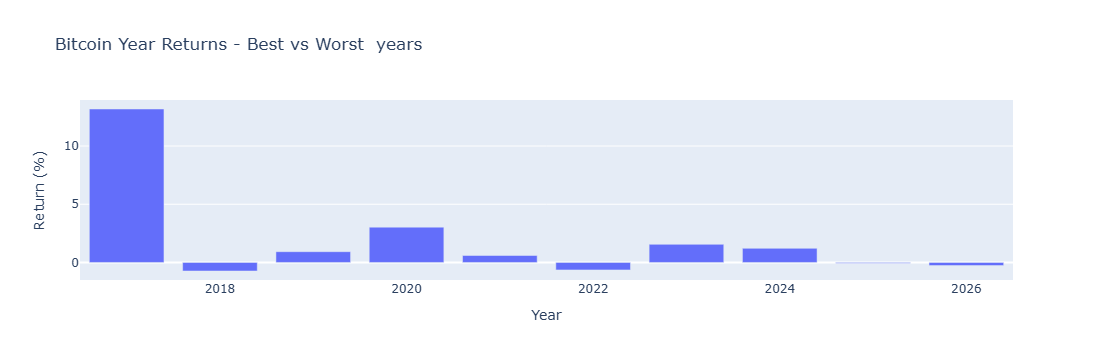

In [98]:
px.bar(yearly_df,
      x = "Year",
      y = "Return (%)",
      title = "Bitcoin Year Returns - Best vs Worst  years")